In [1]:
import pandas as pd

In [2]:
portfolio = pd.read_csv('../data/portfolio.csv', encoding='utf-8')
profile = pd.read_csv('../data/profile.csv', encoding='utf-8')
transcript = pd.read_csv('../data/transcript.csv', encoding='utf-8')

In [3]:
portfolio.shape

(10, 7)

In [4]:
profile.shape

(17000, 6)

In [5]:
transcript.shape

(306534, 5)

### portfolio

In [6]:
portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  10 non-null     int64 
 1   reward      10 non-null     int64 
 2   channels    10 non-null     object
 3   difficulty  10 non-null     int64 
 4   duration    10 non-null     int64 
 5   offer_type  10 non-null     object
 6   id          10 non-null     object
dtypes: int64(4), object(3)
memory usage: 692.0+ bytes


In [7]:
portfolio.describe()

,Unnamed: 0,reward,difficulty,duration
count,10.00000,10.000000,10.000000,10.000000
mean,4.50000,4.200000,7.700000,6.500000
std,3.02765,3.583915,5.831905,2.321398
min,0.00000,0.000000,0.000000,3.000000
25%,2.25000,2.000000,5.000000,5.000000
50%,4.50000,4.000000,8.500000,7.000000
75%,6.75000,5.000000,10.000000,7.000000
max,9.00000,10.000000,20.000000,10.000000


In [8]:
portfolio['channels'].value_counts()

channels
['web', 'email', 'mobile', 'social']    4
['web', 'email', 'mobile']              3
['email', 'mobile', 'social']           2
['web', 'email']                        1
Name: count, dtype: int64

In [9]:
portfolio['offer_type'].value_counts()

offer_type
bogo             4
discount         4
informational    2
Name: count, dtype: int64

### profile

In [10]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  object 
 2   age               17000 non-null  int64  
 3   id                17000 non-null  object 
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 797.0+ KB


In [11]:
profile['gender'].value_counts()

gender
M    8484
F    6129
O     212
Name: count, dtype: int64

In [12]:
profile['age'].describe()

count    17000.000000
mean        62.531412
std         26.738580
min         18.000000
25%         45.000000
50%         58.000000
75%         73.000000
max        118.000000
Name: age, dtype: float64

In [13]:
profile.isna().sum()

Unnamed: 0             0
gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [14]:
profile['Unnamed: 0'].value_counts()

Unnamed: 0
0        1
1        1
2        1
3        1
4        1
        ..
16995    1
16996    1
16997    1
16998    1
16999    1
Name: count, Length: 17000, dtype: int64

### transcript

In [15]:
transcript.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  306534 non-null  int64 
 1   person      306534 non-null  object
 2   event       306534 non-null  object
 3   value       306534 non-null  object
 4   time        306534 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.7+ MB


In [16]:
transcript['time'].describe()

count    306534.000000
mean        366.382940
std         200.326314
min           0.000000
25%         186.000000
50%         408.000000
75%         528.000000
max         714.000000
Name: time, dtype: float64

In [17]:
transcript['event'].value_counts()

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64

In [18]:
transcript['value'].value_counts()

value
{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'}    14983
{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}    14924
{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}    14891
{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}    14835
{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'}    14374
                                                    ...  
{'amount': 39.54}                                       1
{'amount': 306.99}                                      1
{'amount': 49.73}                                       1
{'amount': 749.29}                                      1
{'amount': 286.81}                                      1
Name: count, Length: 5121, dtype: int64

### 전처리 및 EDA 가설 1) 연령=118은 미가입자일 것이다.
- 가설이 충족하려면 연령=118인 사람 == gender와 income이 NaN

In [19]:
# 1. 118세인 고객들만 필터링하여 새로운 데이터프레임 생성
profile_118 = profile[profile['age'] == 118].copy()

# 2. 제대로 뽑혔는지 확인 (상위 30개 행)
print(f"118세 고객 수: {len(profile_118)}명")
display(profile_118.head(30))

# 3. (PM 추천) 이들의 성별과 소득도 비어있는지 한눈에 확인하기
print("\n[118세 고객의 결측치 현황]")
print(profile_118.isnull().sum())

118세 고객 수: 2175명


,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
6,6,NaN,118,8ec6ce2a7e7949b1bf142def7d0e0586,20170925,NaN
7,7,NaN,118,68617ca6246f4fbc85e91a2a49552598,20171002,NaN
9,9,NaN,118,8974fc5686fe429db53ddde067b88302,20161122,NaN
10,10,NaN,118,c4863c7985cf408faee930f111475da3,20170824,NaN
11,11,NaN,118,148adfcaa27d485b82f323aaaad036bd,20150919,NaN
17,17,NaN,118,744d603ef08c4f33af5a61c8c7628d1c,20170801,NaN
23,23,NaN,118,2b826eba31074a059d63b0ae8f50b7d5,20170907,NaN



[118세 고객의 결측치 현황]
Unnamed: 0             0
gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64


- 이상한 걸 발견함
- 가입일자가... 있어........
- 그래서 뭘 할거냐면... 118세인 사람과 그렇지 않은 사람이 뭐가 다른지 분석해볼겁니다.

In [20]:
# 'is_missing' 컬럼 생성 (118세면 1, 아니면 0)
profile['is_missing'] = (profile['age'] == 118).astype(int)
profile.head()

,Unnamed: 0,gender,age,id,became_member_on,income,is_missing
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,1
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0,0
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN,1
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0,0
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN,1


### Merge
- transcript를 왼쪽, profile을 오른쪽으로 left join

In [21]:
import pandas as pd

# 1. Left Join 수행 (transcript가 왼쪽, profile이 오른쪽)
# left_on에는 transcript의 키, right_on에는 profile의 키를 넣습니다.
df_merged = pd.merge(transcript, profile, left_on='person', right_on='id', how='left')

# 2. 병합 후 데이터 확인
print(f"병합 전 로그 수: {len(transcript)}행")
print(f"병합 후 로그 수: {len(df_merged)}행") # Left Join이므로 행 수가 동일해야 정상입니다.

# 3. 제대로 붙었는지 확인 (앞선 118세 플래그 'is_missing' 포함 여부)
display(df_merged.head())

# 4. 병합 후 결측치 체크 (중요!)
# profile에 없는 유저가 transcript에 있다면 age 등에 NaN이 생깁니다.
print("\n[병합 후 데이터 결측치 확인]")
print(df_merged.isnull().sum())

병합 전 로그 수: 306534행
병합 후 로그 수: 306534행


,Unnamed: 0_x,person,event,value,time,Unnamed: 0_y,gender,age,id,became_member_on,income,is_missing
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0,0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN,1
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,5,M,68,e2127556f4f64592b11af22de27a7932,20180426,70000.0,0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,6,NaN,118,8ec6ce2a7e7949b1bf142def7d0e0586,20170925,NaN,1
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,7,NaN,118,68617ca6246f4fbc85e91a2a49552598,20171002,NaN,1



[병합 후 데이터 결측치 확인]
Unnamed: 0_x            0
person                  0
event                   0
value                   0
time                    0
Unnamed: 0_y            0
gender              33772
age                     0
id                      0
became_member_on        0
income              33772
is_missing              0
dtype: int64


In [22]:
import pandas as pd
import ast

# 1. 'value' 컬럼의 데이터가 문자열일 경우를 대비해 딕셔너리 객체로 변환
# (이미 딕셔너리라면 이 단계는 무시되거나 안전하게 처리됩니다)
def convert_to_dict(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

# 2. 'value' 컬럼을 다시 딕셔너리로 확실히 변환
# 캡처본 보니 'value' 컬럼에 데이터가 들어있으므로 이를 기준으로 처리합니다.
df_merged['value'] = df_merged['value'].apply(convert_to_dict)

# 3. 다시 컬럼 펼치기
value_expanded = pd.json_normalize(df_merged['value'])

# 4. 기존 데이터와 합치고 'value' 컬럼 삭제
df_merged = pd.concat([df_merged.drop(columns=['value']), value_expanded], axis=1)

# 5. 컬럼명 정리 (offer id -> offer_id 통합)
if 'offer_id' in df_merged.columns and 'offer id' in df_merged.columns:
    df_merged['offer_id'] = df_merged['offer_id'].fillna(df_merged['offer id'])
    df_merged = df_merged.drop(columns=['offer id'])
if 'offer id' in df_merged.columns:
    df_merged.rename(columns={'offer id': 'offer_id'}, inplace=True)


# 결과 확인
print(f"수정 후 컬럼 목록: {df_merged.columns.tolist()}")
display(df_merged.head())

수정 후 컬럼 목록: ['Unnamed: 0_x', 'person', 'event', 'time', 'Unnamed: 0_y', 'gender', 'age', 'id', 'became_member_on', 'income', 'is_missing', 'amount', 'offer_id', 'reward']


,Unnamed: 0_x,person,event,time,Unnamed: 0_y,gender,age,id,became_member_on,income,is_missing,amount,offer_id,reward
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,0,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN,1,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,2,e2127556f4f64592b11af22de27a7932,offer received,0,5,M,68,e2127556f4f64592b11af22de27a7932,20180426,70000.0,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,6,NaN,118,8ec6ce2a7e7949b1bf142def7d0e0586,20170925,NaN,1,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,0,7,NaN,118,68617ca6246f4fbc85e91a2a49552598,20171002,NaN,1,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN


In [23]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0_x      306534 non-null  int64  
 1   person            306534 non-null  object 
 2   event             306534 non-null  object 
 3   time              306534 non-null  int64  
 4   Unnamed: 0_y      306534 non-null  int64  
 5   gender            272762 non-null  object 
 6   age               306534 non-null  int64  
 7   id                306534 non-null  object 
 8   became_member_on  306534 non-null  int64  
 9   income            272762 non-null  float64
 10  is_missing        306534 non-null  int64  
 11  amount            138953 non-null  float64
 12  offer_id          167581 non-null  object 
 13  reward            33579 non-null   float64
dtypes: float64(3), int64(6), object(5)
memory usage: 32.7+ MB


In [24]:
# 중복 및 불필요한 컬럼 삭제
# 'person'과 내용이 겹치는 'id' 컬럼과, 이미 풀어낸 'value' 컬럼을 제거합니다.
df_merged = df_merged.drop(columns=['id', 'Unnamed: 0_x', 'Unnamed: 0_y'])

# 5. 결과 확인
print(f"전처리 후 컬럼 목록: {df_merged.columns.tolist()}")
display(df_merged.head())

전처리 후 컬럼 목록: ['person', 'event', 'time', 'gender', 'age', 'became_member_on', 'income', 'is_missing', 'amount', 'offer_id', 'reward']


,person,event,time,gender,age,became_member_on,income,is_missing,amount,offer_id,reward
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,F,75,20170509,100000.0,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,118,20170804,NaN,1,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,M,68,20180426,70000.0,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,118,20170925,NaN,1,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,118,20171002,NaN,1,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN


- 행이 중간에 잘려서...... 아무튼 안 잘리게 설정

In [25]:
# 1. 최대 행(rows) 수 설정 (None으로 설정하면 제한 없이 모두 보여줍니다)
pd.set_option('display.max_rows', 100) 

# 2. 만약 컬럼(columns)도 잘린다면 이것도 설정해 주세요
pd.set_option('display.max_columns', None)

# 3. 컬럼 안의 내용이 너무 길어서 잘릴 때 (예: value 안의 딕셔너리 내용 등)
pd.set_option('display.max_colwidth', None)

- 다시 원래대로 돌리고 싶으면 아래 주석을 실행하면 됨

In [26]:
# pd.reset_option('display.max_rows')

In [27]:
# is_missing이 1인 행만 필터링하여 새로운 변수에 담기
missing_group_logs = df_merged[df_merged['is_missing'] == 1]

# 해당 그룹의 이벤트(event) 구성비 확인
print("[118세 그룹의 이벤트 발생 현황]")
print(missing_group_logs['event'].value_counts())
print("-" * 30)
print(missing_group_logs['event'].value_counts(normalize=True)) # 비중으로 보기

# 이벤트와 벨류(value) 상세 조회 (상위 10개)
display(missing_group_logs[['person', 'event', 'time', 'amount', 'offer_id', 'reward']].head(10))

[118세 그룹의 이벤트 발생 현황]
event
transaction        14996
offer received      9776
offer viewed        7865
offer completed     1135
Name: count, dtype: int64
------------------------------
event
transaction        0.444036
offer received     0.289471
offer viewed       0.232885
offer completed    0.033608
Name: proportion, dtype: float64


,person,event,time,amount,offer_id,reward
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN
6,c4863c7985cf408faee930f111475da3,offer received,0,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN
10,744d603ef08c4f33af5a61c8c7628d1c,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
11,3d02345581554e81b7b289ab5e288078,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
17,65aba5c617294649aeb624da249e1ee5,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
23,4beeb3ed64dd4898b0edf2f6b67426d3,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
25,25c906289d154b66bf579693f89481c9,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
29,8be4463721e14d7fa600686bf8c8b2ed,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN


- 동시에 쿠폰을 대량으로 뿌린 것 같아서 그냥 특정 범위를 잘라서 보기로 함

In [28]:
# 2500~2600행의 'event'와 'value' 컬럼만 보기
display(missing_group_logs.loc[missing_group_logs.index[2500:2600], ['person', 'event', 'time', 'amount', 'offer_id', 'reward']])

,person,event,time,amount,offer_id,reward
20012,ff171032c3484478ae213de018a51402,transaction,12,2.42,NaN,NaN
20022,1e663ba7cf0a420e93a1ed185db67c78,transaction,12,3.04,NaN,NaN
20024,7416cb5cf81143469b26c7638388b634,transaction,12,1.83,NaN,NaN
20038,aefcc0baa56342649e3549e6cbc6d1e5,offer viewed,12,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
20039,d9ae18fe286c4a8ab44086a7f930c0f3,offer viewed,12,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
20045,2033fe44df8c4236b57828dc032a6115,transaction,12,1.66,NaN,NaN
20053,8d7c5413f98d405e88fd4f35cb705780,offer viewed,12,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
20105,25949880f9e34890b538eda513169a9d,offer viewed,12,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN
20125,226d2222e82e48b4a62b17eb416bb0a2,offer viewed,12,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN
20141,8ae49e01c5cc4029ad3758b6081b3bfd,transaction,12,0.22,NaN,NaN


In [29]:
# 118세 그룹 중 샘플 유저 한 명의 ID를 뽑습니다.
sample_user = missing_group_logs['person'].iloc[0]

# 그 유저의 모든 기록을 시간(time)순으로 정렬해서 봅니다.
user_timeline = df_merged[df_merged['person'] == sample_user].sort_values('time')
display(user_timeline[['time', 'event', 'amount', 'offer_id', 'reward']])

,time,event,amount,offer_id,reward
1,0,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
15562,6,offer viewed,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
90553,234,transaction,1.09,NaN,NaN
97700,264,transaction,3.50,NaN,NaN
110829,336,offer received,NaN,3f207df678b143eea3cee63160fa8bed,NaN
123539,336,offer viewed,NaN,3f207df678b143eea3cee63160fa8bed,NaN
150599,408,offer received,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN
201573,504,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
245125,576,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
277104,612,transaction,0.06,NaN,NaN


In [30]:
# 118세 그룹 중 샘플 유저 한 명의 ID를 뽑습니다.
sample_user = missing_group_logs['person'].iloc[110]

# 그 유저의 모든 기록을 시간(time)순으로 정렬해서 봅니다.
user_timeline = df_merged[df_merged['person'] == sample_user].sort_values('time')
display(user_timeline[['time', 'event', 'amount', 'offer_id', 'reward']])

,time,event,amount,offer_id,reward
803,0,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
13746,0,offer viewed,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
53959,168,offer received,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
109314,324,transaction,3.61,NaN,NaN
111627,336,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
124954,336,offer viewed,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
155359,408,offer received,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN
202365,504,offer received,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN
219735,510,transaction,5.62,NaN,NaN
245914,576,offer received,NaN,2906b810c7d4411798c6938adc9daaa5,NaN


In [31]:
# 118세 그룹 중 샘플 유저 한 명의 ID를 뽑습니다.
sample_user = missing_group_logs['person'].iloc[1500]

# 그 유저의 모든 기록을 시간(time)순으로 정렬해서 봅니다.
user_timeline = df_merged[df_merged['person'] == sample_user].sort_values('time')
display(user_timeline[['time', 'event', 'amount', 'offer_id', 'reward']])

,time,event,amount,offer_id,reward
11756,0,offer received,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
27737,36,offer viewed,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN
53105,162,transaction,2.82,NaN,NaN
77064,186,transaction,3.61,NaN,NaN
97586,258,transaction,3.09,NaN,NaN
108846,318,transaction,1.18,NaN,NaN
122601,336,offer received,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN
162432,408,offer received,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN
177065,426,offer viewed,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN
256954,576,offer received,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN


In [32]:
# 118세 그룹 중 샘플 유저 한 명의 ID를 뽑습니다.
sample_user = missing_group_logs['person'].iloc[6200]

# 그 유저의 모든 기록을 시간(time)순으로 정렬해서 봅니다.
user_timeline = df_merged[df_merged['person'] == sample_user].sort_values('time')
display(user_timeline[['time', 'event', 'amount', 'offer_id', 'reward']])

,time,event,amount,offer_id,reward
31465,54,transaction,4.29,NaN,NaN
44611,114,transaction,0.72,NaN,NaN
56252,168,offer received,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN
69993,174,offer viewed,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN
185438,450,transaction,1.17,NaN,NaN
228472,528,transaction,5.22,NaN,NaN
248142,576,offer received,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN
272435,600,offer viewed,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN


In [33]:
# 118세 그룹 중 샘플 유저 한 명의 ID를 뽑습니다.
sample_user = missing_group_logs['person'].iloc[20500]

# 그 유저의 모든 기록을 시간(time)순으로 정렬해서 봅니다.
user_timeline = df_merged[df_merged['person'] == sample_user].sort_values('time')
display(user_timeline[['time', 'event', 'amount', 'offer_id', 'reward']])

,time,event,amount,offer_id,reward
10499,0,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
19864,12,offer viewed,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
19865,12,transaction,7.93,NaN,NaN
19866,12,offer completed,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,5.0
36636,72,transaction,4.79,NaN,NaN
47376,126,transaction,0.55,NaN,NaN
49305,138,transaction,1.04,NaN,NaN
63703,168,offer received,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN
83028,204,offer viewed,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN
88572,222,transaction,1.51,NaN,NaN


In [34]:
# 118세 그룹 중 샘플 유저 한 명의 ID를 뽑습니다.
sample_user = missing_group_logs['person'].iloc[30000]

# 그 유저의 모든 기록을 시간(time)순으로 정렬해서 봅니다.
user_timeline = df_merged[df_merged['person'] == sample_user].sort_values('time')
display(user_timeline[['time', 'event', 'amount', 'offer_id', 'reward']])

,time,event,amount,offer_id,reward
6,0,offer received,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN
22297,24,offer viewed,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN
34053,66,transaction,0.89,NaN,NaN
110833,336,offer received,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN
130151,348,offer viewed,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN
132805,354,transaction,3.46,NaN,NaN
145373,390,transaction,0.58,NaN,NaN
148928,402,transaction,1.28,NaN,NaN
193185,474,transaction,0.19,NaN,NaN
243230,570,transaction,0.13,NaN,NaN


#### 정상집단..

In [35]:
# is_missing이 0인 행만 필터링하여 새로운 변수에 담기
normal_group_logs = df_merged[df_merged['is_missing'] == 0]

# 해당 그룹의 이벤트(event) 구성비 확인
print("[118세 아닌 그룹의 이벤트 발생 현황]")
print(normal_group_logs['event'].value_counts())
print("-" * 30)
print(normal_group_logs['event'].value_counts(normalize=True)) # 비중으로 보기

# 이벤트와 벨류(value) 상세 조회 (상위 10개)
display(normal_group_logs[['person', 'event', 'time', 'amount', 'offer_id', 'reward']].head(10))

[118세 아닌 그룹의 이벤트 발생 현황]
event
transaction        123957
offer received      66501
offer viewed        49860
offer completed     32444
Name: count, dtype: int64
------------------------------
event
transaction        0.454451
offer received     0.243806
offer viewed       0.182797
offer completed    0.118946
Name: proportion, dtype: float64


,person,event,time,amount,offer_id,reward
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN
5,389bc3fa690240e798340f5a15918d5c,offer received,0,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN
7,2eeac8d8feae4a8cad5a6af0499a211d,offer received,0,NaN,3f207df678b143eea3cee63160fa8bed,NaN
8,aa4862eba776480b8bb9c68455b8c2e1,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
9,31dda685af34476cad5bc968bdb01c53,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
12,4b0da7e80e5945209a1fdddfe813dbe0,offer received,0,NaN,ae264e3637204a6fb9bb56bc8210ddfd,NaN
13,c27e0d6ab72c455a8bb66d980963de60,offer received,0,NaN,3f207df678b143eea3cee63160fa8bed,NaN
14,d53717f5400c4e84affdaeda9dd926b3,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN
15,f806632c011441378d4646567f357a21,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN


In [36]:
# 118세 아닌 그룹 중 샘플 유저 한 명의 ID를 뽑습니다.
sample_user2 = normal_group_logs['person'].iloc[0]

# 그 유저의 모든 기록을 시간(time)순으로 정렬해서 봅니다.
user_timeline = df_merged[df_merged['person'] == sample_user2].sort_values('time')
display(user_timeline[['time', 'event', 'amount', 'offer_id', 'reward']])

,time,event,amount,offer_id,reward
0,0,offer received,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
15561,6,offer viewed,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN
47582,132,transaction,19.89,NaN,NaN
47583,132,offer completed,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,5.0
49502,144,transaction,17.78,NaN,NaN
53176,168,offer received,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN
85291,216,offer viewed,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN
87134,222,transaction,19.67,NaN,NaN
92104,240,transaction,29.72,NaN,NaN
141566,378,transaction,23.93,NaN,NaN


In [37]:
# 118세 아닌 그룹 중 샘플 유저 한 명의 ID를 뽑습니다.
sample_user2 = normal_group_logs['person'].iloc[125]

# 그 유저의 모든 기록을 시간(time)순으로 정렬해서 봅니다.
user_timeline = df_merged[df_merged['person'] == sample_user2].sort_values('time')
display(user_timeline[['time', 'event', 'amount', 'offer_id', 'reward']])

,time,event,amount,offer_id,reward
144,0,offer received,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN
18093,12,offer viewed,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN
22334,24,transaction,18.93,NaN,NaN
22335,24,offer completed,NaN,f19421c1d4aa40978ebb69ca19b0e20d,5.0
35555,72,transaction,18.13,NaN,NaN
46606,126,transaction,14.86,NaN,NaN
53320,168,offer received,NaN,3f207df678b143eea3cee63160fa8bed,NaN
81417,204,offer viewed,NaN,3f207df678b143eea3cee63160fa8bed,NaN
81418,204,transaction,16.72,NaN,NaN
92121,240,transaction,23.28,NaN,NaN


- time이 0일 때 모든 이벤트가 received인가?

In [38]:
# 1. time이 0인 데이터만 필터링
time_zero_data = df_merged[df_merged['time'] == 0]

# 2. 해당 시점의 이벤트 종류별 개수 확인
event_counts_at_zero = time_zero_data['event'].value_counts()

print("--- time이 0일 때 발생한 이벤트 목록 ---")
print(event_counts_at_zero)

# 3. 만약 'offer received'가 아닌 이벤트가 있다면 비율로 확인
print("\n--- 이벤트 발생 비중 ---")
print(time_zero_data['event'].value_counts(normalize=True))

--- time이 0일 때 발생한 이벤트 목록 ---
event
offer received     12650
offer viewed        2072
transaction          633
offer completed      206
Name: count, dtype: int64

--- 이벤트 발생 비중 ---
event
offer received     0.812930
offer viewed       0.133153
transaction        0.040679
offer completed    0.013238
Name: proportion, dtype: float64


- 0초에 completed된 사람은 누구인가?

In [39]:
# time이 0인데 이미 completed를 찍은 사람들의 특징 확인
instant_completers = time_zero_data[time_zero_data['event'] == 'offer completed']

# 이들이 118세 그룹(is_missing=1)인지 확인
print(instant_completers['is_missing'].value_counts())

is_missing
0    204
1      2
Name: count, dtype: int64


- 혹시 118세 그룹은 time==0에 받은 쿠폰이 없는 게 아닐까?\
- 결과: 그건 아닌 것 같다

In [40]:
# 그룹별로 time==0에 받은 쿠폰 수 비교
zero_comparison = time_zero_data.groupby('is_missing')['event'].count()
print("--- 그룹별 0시점 쿠폰 수령 건수 ---")
print(zero_comparison)

--- 그룹별 0시점 쿠폰 수령 건수 ---
is_missing
0    13545
1     2016
Name: event, dtype: int64


### 3개 테이블 모두 병합

In [41]:
# 1. Left Join 수행 (df_merged가 왼쪽, portfolio이 오른쪽)
df_final = pd.merge(df_merged, portfolio, left_on='offer_id', right_on='id', how='left')

# 2. 병합 후 데이터 확인
print(f"병합 전 로그 수: {len(df_merged)}행")
print(f"병합 후 로그 수: {len(df_final)}행") # Left Join이므로 행 수가 동일해야 정상입니다.

# 3. 제대로 붙었는지 확인
display(df_final.head())

# 4. 병합 후 결측치 체크 (중요!)
print("\n[병합 후 데이터 결측치 확인]")
print(df_final.isnull().sum())

병합 전 로그 수: 306534행
병합 후 로그 수: 306534행


,person,event,time,gender,age,became_member_on,income,is_missing,amount,offer_id,reward_x,Unnamed: 0,reward_y,channels,difficulty,duration,offer_type,id
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,F,75,20170509,100000.0,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,3.0,5.0,"['web', 'email', 'mobile']",5.0,7.0,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,118,20170804,NaN,1,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,4.0,5.0,"['web', 'email']",20.0,10.0,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
2,e2127556f4f64592b11af22de27a7932,offer received,0,M,68,20180426,70000.0,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,9.0,2.0,"['web', 'email', 'mobile']",10.0,7.0,discount,2906b810c7d4411798c6938adc9daaa5
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,118,20170925,NaN,1,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,6.0,2.0,"['web', 'email', 'mobile', 'social']",10.0,10.0,discount,fafdcd668e3743c1bb461111dcafc2a4
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,118,20171002,NaN,1,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,1.0,10.0,"['web', 'email', 'mobile', 'social']",10.0,5.0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0



[병합 후 데이터 결측치 확인]
person                   0
event                    0
time                     0
gender               33772
age                      0
became_member_on         0
income               33772
is_missing               0
amount              167581
offer_id            138953
reward_x            272955
Unnamed: 0          138953
reward_y            138953
channels            138953
difficulty          138953
duration            138953
offer_type          138953
id                  138953
dtype: int64


- offer_id와 id가 동일하면 하나만 있어도 됨
- reward_x는 소비자가 받은 리워드
- reward_y는 프로모션 완료 시 들어가는 리워듴

In [42]:
# 1. 두 컬럼(offer_id, id)이 완전히 일치하는지 확인
# (NaN 값은 비교에서 제외하거나 동일하게 처리해야 하므로 fillna 사용)
is_equal = df_final['offer_id'].fillna('') == df_final['id'].fillna('')

if is_equal.all():
    print("두 컬럼이 100% 일치합니다. 'id' 컬럼을 삭제합니다.")
    df_final = df_final.drop(columns=['id'])
else:
    print("일부 행에서 데이터가 일치하지 않습니다. 확인이 필요합니다.")
    # 일치하지 않는 행만 출력해서 확인해보기
    display(df_final[~is_equal][['offer_id', 'id']].head())

# 2. 리워드 컬럼 이름 정리 (직관적으로 변경)
df_final = df_final.rename(columns={
    'reward_x': 'actual_reward',
    'reward_y': 'offer_reward'
})

display(df_final.head())

두 컬럼이 100% 일치합니다. 'id' 컬럼을 삭제합니다.


,person,event,time,gender,age,became_member_on,income,is_missing,amount,offer_id,actual_reward,Unnamed: 0,offer_reward,channels,difficulty,duration,offer_type
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,F,75,20170509,100000.0,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,3.0,5.0,"['web', 'email', 'mobile']",5.0,7.0,bogo
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,118,20170804,NaN,1,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,4.0,5.0,"['web', 'email']",20.0,10.0,discount
2,e2127556f4f64592b11af22de27a7932,offer received,0,M,68,20180426,70000.0,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,9.0,2.0,"['web', 'email', 'mobile']",10.0,7.0,discount
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,118,20170925,NaN,1,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,6.0,2.0,"['web', 'email', 'mobile', 'social']",10.0,10.0,discount
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,118,20171002,NaN,1,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,1.0,10.0,"['web', 'email', 'mobile', 'social']",10.0,5.0,bogo


In [43]:
df_final.info()
# offer_reward = 프로모션 완료 시 주어지기로 한 리워드
# actual_reward = 실제 고객에게 주어진 리워드

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306534 non-null  object 
 1   event             306534 non-null  object 
 2   time              306534 non-null  int64  
 3   gender            272762 non-null  object 
 4   age               306534 non-null  int64  
 5   became_member_on  306534 non-null  int64  
 6   income            272762 non-null  float64
 7   is_missing        306534 non-null  int64  
 8   amount            138953 non-null  float64
 9   offer_id          167581 non-null  object 
 10  actual_reward     33579 non-null   float64
 11  Unnamed: 0        167581 non-null  float64
 12  offer_reward      167581 non-null  float64
 13  channels          167581 non-null  object 
 14  difficulty        167581 non-null  float64
 15  duration          167581 non-null  float64
 16  offer_type        16

In [44]:
df_final['offer_id'].value_counts()

offer_id
fafdcd668e3743c1bb461111dcafc2a4    20241
2298d6c36e964ae4a3e7e9706d1fb8c2    20139
f19421c1d4aa40978ebb69ca19b0e20d    19131
4d5c57ea9a6940dd891ad53e9dbe8da0    18222
ae264e3637204a6fb9bb56bc8210ddfd    18062
9b98b8c7a33c4b65b9aebfe6a799e6d9    16202
2906b810c7d4411798c6938adc9daaa5    15767
5a8bc65990b245e5a138643cd4eb9837    14305
0b1e1539f2cc45b7b9fa7c272da2e1d7    13751
3f207df678b143eea3cee63160fa8bed    11761
Name: count, dtype: int64

### offer를 구별하기 힘들어서 새 컬럼으로 offer 이름을 지어주려 합니다

In [45]:
# 1. 중복 없는 오퍼 목록과 속성 확인
offer_info = df_final[['offer_id', 'offer_type', 'difficulty', 'offer_reward']].drop_duplicates().sort_values('offer_type')

# 2. 결과 출력 (이걸 보고 이름을 어떻게 지을지 결정하면 됩니다)
display(offer_info)

,offer_id,offer_type,difficulty,offer_reward
0,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5.0,5.0
4,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10.0,10.0
5,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0
12,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10.0,10.0
1,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,20.0,5.0
2,2906b810c7d4411798c6938adc9daaa5,discount,10.0,2.0
3,fafdcd668e3743c1bb461111dcafc2a4,discount,10.0,2.0
6,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,7.0,3.0
7,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0
31,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0


In [46]:
# 1. ID와 우리가 정한 이름을 매핑 (예시입니다. 위에서 출력된 offer_info를 보고 수정하세요)
offer_name_map = {
    'ae264e3637204a6fb9bb56bc8210ddfd': 'bogo_10_10',       # 10불 쓰고 10불 받는 BOGO
    '4d5c57ea9a6940dd891ad53e9dbe8da0': 'bogo_10_10_v2',    # 10불 쓰고 10불 받는 BOGO 2
    '9b98b8c7a33c4b65b9aebfe6a799e6d9': 'bogo_5_5',         # 5불 쓰고 5불 받는 BOGO
    'f19421c1d4aa40978ebb69ca19b0e20d': 'bogo_5_5_v2',      # 5불 쓰고 5불 받는 BOGO 2
    '3f207df678b143eea3cee63160fa8bed': 'info_1',           # 정보성 (보상 없음) 1
    '5a8bc65990b245e5a138643cd4eb9837': 'info_2',           # 정보성 (보상 없음) 2
    '0b1e1539f2cc45b7b9fa7c272da2e1d7': 'discount_20_5',    # 20불 쓰고 5불 할인
    '2906b810c7d4411798c6938adc9daaa5': 'discount_10_2',    # 10불 쓰고 2불 할인
    'fafdcd668e3743c1bb461111dcafc2a4': 'discount_10_2_v2', # 10불 쓰고 2불 할인 2
    '2298d6c36e964ae4a3e7e9706d1fb8c2': 'discount_7_3'      # 7불 쓰고 3불 할인
}

# 2. 새로운 컬럼 생성
df_final['offer_name'] = df_final['offer_id'].map(offer_name_map)

# 3. 잘 들어갔는지 확인
display(df_final[['offer_id', 'offer_type', 'offer_name']].drop_duplicates())

,offer_id,offer_type,offer_name
0,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,bogo_5_5
1,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,discount_20_5
2,2906b810c7d4411798c6938adc9daaa5,discount,discount_10_2
3,fafdcd668e3743c1bb461111dcafc2a4,discount,discount_10_2_v2
4,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,bogo_10_10_v2
5,f19421c1d4aa40978ebb69ca19b0e20d,bogo,bogo_5_5_v2
6,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,discount_7_3
7,3f207df678b143eea3cee63160fa8bed,informational,info_1
12,ae264e3637204a6fb9bb56bc8210ddfd,bogo,bogo_10_10
31,5a8bc65990b245e5a138643cd4eb9837,informational,info_2


- 약식으로 본 오퍼별 전환율

In [47]:
# 고객별, 오퍼별, 시간별로 정렬하여 여정을 순서대로 만듦
df_sorted = df_final.sort_values(['person', 'offer_id', 'time'])

# 오퍼별 이벤트 발생 여부 체크 (피벗 테이블 활용)
# 고객별+오퍼별로 어떤 이벤트들이 일어났는지 1과 0으로 표시
offer_journey = df_sorted.groupby(['person', 'offer_id', 'offer_name'])['event'].value_counts().unstack().fillna(0)

# 컬럼 이름 정리 (이벤트가 없으면 컬럼이 안 생길 수 있으니 확인 후 추가)
for col in ['offer received', 'offer viewed', 'offer completed']:
    if col not in offer_journey.columns:
        offer_journey[col] = 0

# '진성 전환' 여부 판단 (보고 썼는가?)
# (사실 여기서 '시간 순서'까지 체크하려면 더 복잡한 로직이 필요하지만, 
# 일차적으로는 Viewed와 Completed가 모두 1 이상인 경우를 성공으로 봅니다.)
offer_journey['is_converted'] = (offer_journey['offer viewed'] > 0) & (offer_journey['offer completed'] > 0)

# 오퍼 이름별(offer_name) 최종 전환율 계산
conversion_rate = offer_journey.groupby('offer_name')['is_converted'].mean() * 100

print("[오퍼별 최종 전환율 %]")
print(conversion_rate.sort_values(ascending=False))

[오퍼별 최종 전환율 %]
offer_name
discount_10_2_v2    70.009476
discount_7_3        68.189723
bogo_5_5_v2         58.367934
bogo_10_10_v2       44.628752
bogo_10_10          44.603075
bogo_5_5            39.402046
discount_10_2       38.424821
discount_20_5       23.093819
info_1               0.000000
info_2               0.000000
Name: is_converted, dtype: float64


In [48]:
offer_journey

event                                                                               offer completed  \
person                           offer_id                         offer_name                          
0009655768c64bdeb2e877511632db8f 2906b810c7d4411798c6938adc9daaa5 discount_10_2                 1.0   
                                 3f207df678b143eea3cee63160fa8bed info_1                        0.0   
                                 5a8bc65990b245e5a138643cd4eb9837 info_2                        0.0   
                                 f19421c1d4aa40978ebb69ca19b0e20d bogo_5_5_v2                   1.0   
                                 fafdcd668e3743c1bb461111dcafc2a4 discount_10_2_v2              1.0   
...                                                                                             ...   
fffad4f4828548d1b5583907f2e9906b f19421c1d4aa40978ebb69ca19b0e20d bogo_5_5_v2                   2.0   
ffff82501cea40309d5fdd7edcca4a07 0b1e1539f2cc45b7b9fa7c272da2e1d7 discount_20_5                 1.0   
                                 2906b810c7d4411798c6938adc9daaa5 discount_10_2                 3.0   
                                 9b98b8c7a33c4b65b9aebfe6a799e6d9 bogo_5_5                      1.0   
                                 fafdcd668e3743c1bb461111dcafc2a4 discount_10_2_v2              1.0   

event                                                                               offer received  \
person                           offer_id                         offer_name                         
0009655768c64bdeb2e877511632db8f 2906b810c7d4411798c6938adc9daaa5 discount_10_2                1.0   
                                 3f207df678b143eea3cee63160fa8bed info_1                       1.0   
                                 5a8bc65990b245e5a138643cd4eb9837 info_2                       1.0   
                                 f19421c1d4aa40978ebb69ca19b0e20d bogo_5_5_v2                  1.0   
                                 fafdcd668e3743c1bb461111dcafc2a4 discount_10_2_v2             1.0   
...                                                                                            ...   
fffad4f4828548d1b5583907f2e9906b f19421c1d4aa40978ebb69ca19b0e20d bogo_5_5_v2                  2.0   
ffff82501cea40309d5fdd7edcca4a07 0b1e1539f2cc45b7b9fa7c272da2e1d7 discount_20_5                1.0   
                                 2906b810c7d4411798c6938adc9daaa5 discount_10_2                3.0   
                                 9b98b8c7a33c4b65b9aebfe6a799e6d9 bogo_5_5                     1.0   
                                 fafdcd668e3743c1bb461111dcafc2a4 discount_10_2_v2             1.0   

event                                                                               offer viewed  \
person                           offer_id                         offer_name                       
0009655768c64bdeb2e877511632db8f 2906b810c7d4411798c6938adc9daaa5 discount_10_2              0.0   
                                 3f207df678b143eea3cee63160fa8bed info_1                     1.0   
                                 5a8bc65990b245e5a138643cd4eb9837 info_2                     1.0   
                                 f19421c1d4aa40978ebb69ca19b0e20d bogo_5_5_v2                1.0   
                                 fafdcd668e3743c1bb461111dcafc2a4 discount_10_2_v2           1.0   
...                                                                                          ...   
fffad4f4828548d1b5583907f2e9906b f19421c1d4aa40978ebb69ca19b0e20d bogo_5_5_v2                2.0   
ffff82501cea40309d5fdd7edcca4a07 0b1e1539f2cc45b7b9fa7c272da2e1d7 discount_20_5              1.0   
                                 2906b810c7d4411798c6938adc9daaa5 discount_10_2              3.0   
                                 9b98b8c7a33c4b65b9aebfe6a799e6d9 bogo_5_5                   1.0   
                                 fafdcd668e3743c1bb461111dcafc2a4 discount_10_2_v2           1.0   

event                           

- 한 유저가 받은 오퍼가 시간순으로 나열되고 있는지
- 동일 유저라는 전제 하에 오퍼별로 시간순으로 나열됨
- transaction은 다 빠진다는 문제가 있긴 함..

In [49]:
df_sorted[df_sorted['person'] == '0009655768c64bdeb2e877511632db8f']

,person,event,time,gender,age,became_member_on,income,is_missing,amount,offer_id,actual_reward,Unnamed: 0,offer_reward,channels,difficulty,duration,offer_type,offer_name
247879,0009655768c64bdeb2e877511632db8f,offer received,576,M,33,20170421,72000.0,0,NaN,2906b810c7d4411798c6938adc9daaa5,NaN,9.0,2.0,"['web', 'email', 'mobile']",10.0,7.0,discount,discount_10_2
258884,0009655768c64bdeb2e877511632db8f,offer completed,576,M,33,20170421,72000.0,0,NaN,2906b810c7d4411798c6938adc9daaa5,2.0,9.0,2.0,"['web', 'email', 'mobile']",10.0,7.0,discount,discount_10_2
113605,0009655768c64bdeb2e877511632db8f,offer received,336,M,33,20170421,72000.0,0,NaN,3f207df678b143eea3cee63160fa8bed,NaN,2.0,0.0,"['web', 'email', 'mobile']",0.0,4.0,informational,info_1
139992,0009655768c64bdeb2e877511632db8f,offer viewed,372,M,33,20170421,72000.0,0,NaN,3f207df678b143eea3cee63160fa8bed,NaN,2.0,0.0,"['web', 'email', 'mobile']",0.0,4.0,informational,info_1
55972,0009655768c64bdeb2e877511632db8f,offer received,168,M,33,20170421,72000.0,0,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN,7.0,0.0,"['email', 'mobile', 'social']",0.0,3.0,informational,info_2
77705,0009655768c64bdeb2e877511632db8f,offer viewed,192,M,33,20170421,72000.0,0,NaN,5a8bc65990b245e5a138643cd4eb9837,NaN,7.0,0.0,"['email', 'mobile', 'social']",0.0,3.0,informational,info_2
153401,0009655768c64bdeb2e877511632db8f,offer received,408,M,33,20170421,72000.0,0,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN,8.0,5.0,"['web', 'email', 'mobile', 'social']",5.0,5.0,bogo,bogo_5_5_v2
168413,0009655768c64bdeb2e877511632db8f,offer completed,414,M,33,20170421,72000.0,0,NaN,f19421c1d4aa40978ebb69ca19b0e20d,5.0,8.0,5.0,"['web', 'email', 'mobile', 'social']",5.0,5.0,bogo,bogo_5_5_v2
187554,0009655768c64bdeb2e877511632db8f,offer viewed,456,M,33,20170421,72000.0,0,NaN,f19421c1d4aa40978ebb69ca19b0e20d,NaN,8.0,5.0,"['web', 'email', 'mobile', 'social']",5.0,5.0,bogo,bogo_5_5_v2
204340,0009655768c64bdeb2e877511632db8f,offer received,504,M,33,20170421,72000.0,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,NaN,6.0,2.0,"['web', 'email', 'mobile', 'social']",10.0,10.0,discount,discount_10_2_v2


C:\Temp\ipykernel_13704\266177020.py:20: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\266177020.py:20: UserWarning: Glyph 54140 (\N{HANGUL SYLLABLE PEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\266177020.py:20: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\266177020.py:20: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\266177020.py:20: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\266177020.py:20: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\266177020.py:20: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Dej

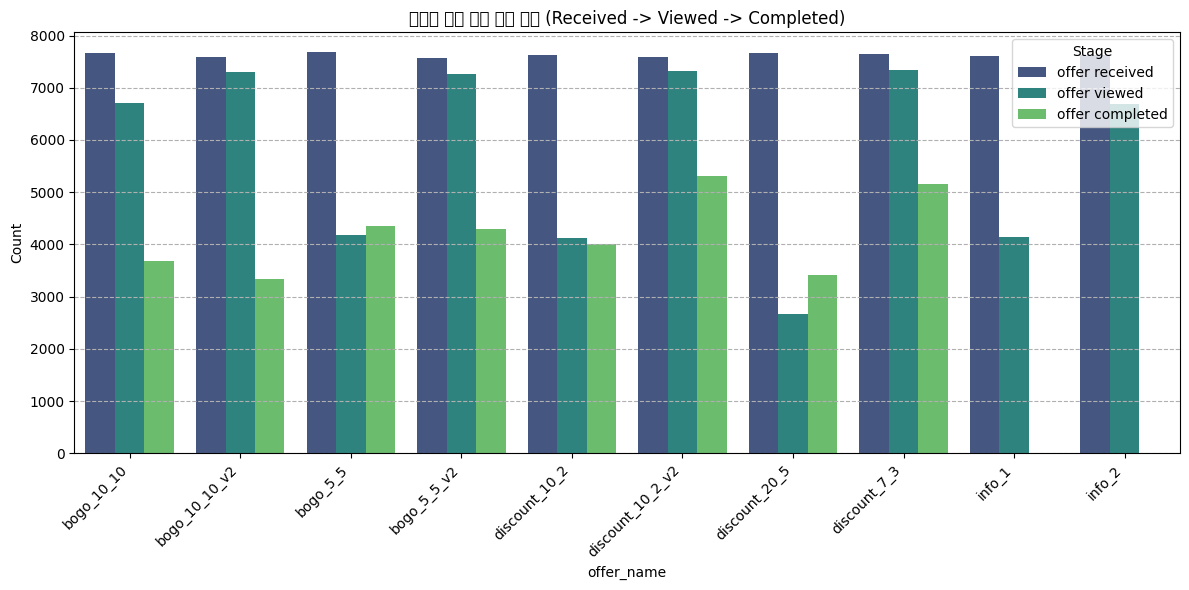

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 오퍼 이름별로 이벤트 합계 집계
# (인덱스에 있는 offer_name을 컬럼으로 빼냅니다)
offer_stats = offer_journey.groupby('offer_name')[['offer received', 'offer viewed', 'offer completed']].sum().reset_index()

# 2. 시각화를 위해 데이터 형태 변환 (Wide -> Long Format)
# seaborn이 좋아하는 형태로 바꿉니다.
offer_stats_melted = offer_stats.melt(id_vars='offer_name', var_name='Stage', value_name='Count')

# 3. 시각화 그리기
plt.figure(figsize=(12, 6))
sns.barplot(data=offer_stats_melted, x='offer_name', y='Count', hue='Stage', palette='viridis')

# 디자인 다듬기
plt.title('오퍼별 고객 여정 단계 비교 (Received -> Viewed -> Completed)')
plt.xticks(rotation=45, ha='right') # x축 글씨가 겹치지 않게 회전
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

C:\Temp\ipykernel_13704\3246256039.py:28: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\3246256039.py:28: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\3246256039.py:28: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\3246256039.py:28: UserWarning: Glyph 54140 (\N{HANGUL SYLLABLE PEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\3246256039.py:28: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\3246256039.py:28: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Temp\ipykernel_13704\3246256039.py:28: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s)

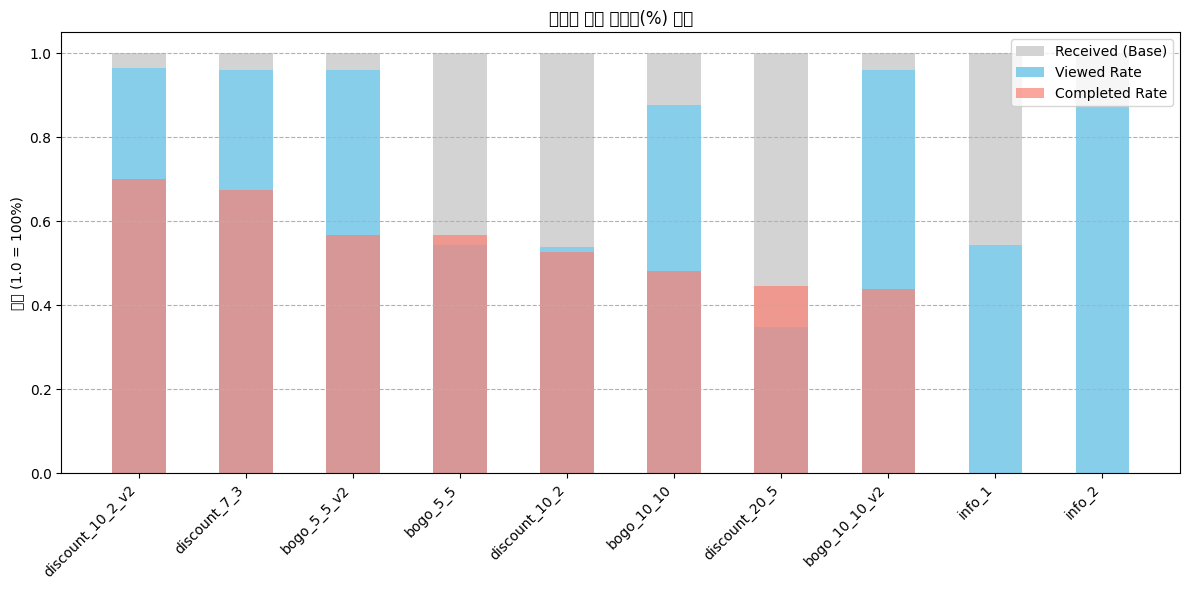

In [51]:
# 1. 각 단계별 비율 계산 (Received를 100% 기준으로)
offer_stats['Viewed Rate'] = offer_stats['offer viewed'] / offer_stats['offer received']
offer_stats['Completed Rate'] = offer_stats['offer completed'] / offer_stats['offer received']
# Received Rate는 항상 1.0 (100%) 입니다.

# 2. 시각화용 데이터 준비
# 보기 좋게 정렬 (완료율 높은 순)
offer_stats_sorted = offer_stats.sort_values('Completed Rate', ascending=False)

# 3. 시각화 그리기 (Matplotlib 기본 기능 활용)
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.5
index = range(len(offer_stats_sorted))

# 층층이 쌓아 올립니다 (뒤에 있는 게 가려지므로 큰 것부터 그립니다)
p1 = ax.bar(index, offer_stats_sorted['offer received'] / offer_stats_sorted['offer received'], bar_width, label='Received (Base)', color='lightgray')
p2 = ax.bar(index, offer_stats_sorted['Viewed Rate'], bar_width, label='Viewed Rate', color='skyblue')
# 주의: Completed가 Viewed보다 높을 수 있으므로 투명도(alpha)를 줍니다.
p3 = ax.bar(index, offer_stats_sorted['Completed Rate'], bar_width, label='Completed Rate', color='salmon', alpha=0.7)

# 디자인 다듬기
ax.set_title('오퍼별 단계 전환율(%) 비교')
ax.set_xticks(index)
ax.set_xticklabels(offer_stats_sorted['offer_name'], rotation=45, ha='right')
ax.set_ylabel('비율 (1.0 = 100%)')
ax.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

### 현실적으로 가능은 한데 정상적인 퍼널 과정이 아닌 케이스 분류

In [52]:
# 1. 고객별, 오퍼별로 각 이벤트가 발생한 '최소 시간'을 구합니다.
# (한 고객이 같은 오퍼를 여러 번 받았을 수 있으니, 가장 먼저 일어난 시점을 기준으로 판단)
event_times = df_final.groupby(['person', 'offer_id', 'event'])['time'].min().unstack()

# 컬럼이 없는 경우를 대비해 기본값 설정
for col in ['offer received', 'offer viewed', 'offer completed']:
    if col not in event_times.columns:
        event_times[col] = pd.NA

# 2. 비정상 케이스 분류 로직
# 케이스 A: 보지도 않았는데 완료된 경우 (Viewed 없이 Completed)
case_blind = event_times[event_times['offer viewed'].isna() & event_times['offer completed'].notna()]

# 케이스 B: 완료가 확인보다 먼저 일어난 경우 (역전 현상)
case_reverse = event_times[event_times['offer viewed'] > event_times['offer completed']]

# 케이스 C: 받았는데 보지도 않고 기간 만료 (무관심)
case_ignored = event_times[event_times['offer viewed'].isna() & event_times['offer completed'].isna()]

print(f"안 보고 완료한(눈먼 리워드) 케이스: {len(case_blind)}건")
print(f"완료 후 확인한(역전) 케이스: {len(case_reverse)}건")
print(f"무관심(받기만 함) 케이스: {len(case_ignored)}건")

# 특정 케이스의 실제 데이터를 보고 싶다면?
display(case_blind.head())

안 보고 완료한(눈먼 리워드) 케이스: 4536건
완료 후 확인한(역전) 케이스: 3708건
무관심(받기만 함) 케이스: 9617건


,event,offer completed,offer received,offer viewed
person,offer_id,,,
0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576.0,576.0,NaN
003d66b6608740288d6cc97a6903f4f0,0b1e1539f2cc45b7b9fa7c272da2e1d7,696.0,504.0,NaN
004c5799adbf42868b9cff0396190900,ae264e3637204a6fb9bb56bc8210ddfd,336.0,336.0,NaN
005500a7188546ff8a767329a2f7c76a,9b98b8c7a33c4b65b9aebfe6a799e6d9,582.0,504.0,NaN
0056df74b63b4298809f0b375a304cf4,0b1e1539f2cc45b7b9fa7c272da2e1d7,414.0,408.0,NaN


In [53]:
# 1. 고객별+오퍼별 이벤트 발생 시간 추출
# 동일 오퍼를 여러 번 받은 경우를 고려해 최초 발생 시간 기준(min)으로 집계
journey_times = df_final.groupby(['person', 'offer_id', 'offer_name', 'event'])['time'].min().unstack()

# 컬럼 누락 방지
for col in ['offer received', 'offer viewed', 'offer completed']:
    if col not in journey_times.columns:
        journey_times[col] = pd.NA

# 2. 케이스 분류 함수 정의
def classify_journey(row):
    received = row['offer received']
    viewed = row['offer viewed']
    completed = row['offer completed']
    
    # Received가 없는 경우는 분석 제외 (데이터 오류 가능성)
    if pd.isna(received):
        return 'Invalid'
    
    # Case 1: 정상 (Received -> Viewed -> Completed 순서)
    if pd.notna(viewed) and pd.notna(completed):
        if received <= viewed <= completed:
            return 'Normal_Conversion'
        elif viewed > completed:
            return 'Completed_Before_View' # 역전 현상
        else:
            return 'Normal_Conversion' # 순서가 맞으면 정상
            
    # Case 2: 단순 확인 (받고 보기만 함)
    if pd.notna(viewed) and pd.isna(completed):
        return 'Viewed_Only'
        
    # Case 3: 눈먼 리워드 (보지 않았는데 완료됨)
    if pd.isna(viewed) and pd.notna(completed):
        return 'Blind_Reward'
        
    # Case 4: 무관심 (받기만 하고 아무것도 안 함)
    if pd.isna(viewed) and pd.isna(completed):
        return 'Ignored'
        
    return 'Other'

# 3. 각 여정에 케이스 적용 (index에 있는 offer_name을 활용하기 위해 reset_index 후 진행)
journey_res = journey_times.reset_index()
journey_res['journey_type'] = journey_res.apply(classify_journey, axis=1)

# 4. 오퍼 이름별로 케이스 비중 집계 (표 만들기)
summary_table = pd.crosstab(journey_res['offer_name'], journey_res['journey_type'], normalize='index') * 100

# 보기 좋게 정렬 (정상 전환율이 높은 순서대로)
summary_table = summary_table.sort_values('Normal_Conversion', ascending=False)

print("[오퍼별 여정 케이스 비중 (%) - 행 단위 합계 100%]")
display(summary_table.round(2))

[오퍼별 여정 케이스 비중 (%) - 행 단위 합계 100%]


journey_type,Blind_Reward,Completed_Before_View,Ignored,Normal_Conversion,Viewed_Only
offer_name,,,,,
discount_10_2_v2,1.53,6.32,1.34,63.69,27.12
discount_7_3,1.71,7.79,1.50,60.40,28.60
bogo_5_5_v2,1.37,8.40,1.85,49.97,38.41
bogo_10_10_v2,0.95,6.15,2.18,38.48,52.24
bogo_10_10,5.24,8.30,5.40,36.30,44.76
bogo_5_5,20.14,9.16,22.30,30.24,18.16
discount_10_2,16.95,8.34,25.65,30.09,18.98
discount_20_5,23.63,4.16,38.72,18.94,14.56
info_1,0.00,0.00,42.58,0.00,57.42
